# Higher-order Shapley interactions in Vision Transformers

**A case study with shapiq, ViT-B/16, and a 3×3 patch grid.**

## Abstract

First-order Shapley values distribute the model prediction across image regions but cannot, by construction, express **how regions interact**. Two regions may individually contribute nothing yet together drive a large prediction (synergy), or each region may contribute strongly but provide redundant evidence so that their joint contribution falls below the sum of parts.

In this notebook we explain a ViT-B/16 prediction with **exact** higher-order interactions using `shapiq.ExactComputer`. We compute the Shapley value (SV), the 2nd-order Shapley Interaction Index (k-SII), and the Shapley-Taylor Interaction Index (STII) on a 3×3 patch grid (9 players, $2^9=512$ coalitions). Concretely, we identify the strongest synergistic and redundant patch pairs, quantify how much of the model's behaviour is captured by interactions that first-order SVs miss, and test whether two ViT masking strategies (`bool_masked_pos` vs. `mask_token`) agree on those strongest pairs.

## Motivation

Most image explanation methods (Grad-CAM, integrated gradients, vanilla SHAP) produce a single heatmap per image. They cannot express that region A only matters in the presence of region B. Interactions are exactly that signal, and shapiq computes them in the same axiomatic framework as the first-order Shapley values.


## 1. Setup

We use ViT-B/16 (`google/vit-base-patch16-224`) on a single image with a 3×3 patch grid as players.
Each player owns a 75×75-pixel block (the patch grid is 14×14 = 196 native ViT tokens, and we group them into 9 macro-regions).

All seeds are fixed. Since `ExactComputer` evaluates all coalitions exhaustively, results are bit-deterministic given the model and the image.


In [10]:
from __future__ import annotations

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
pil_image = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])(raw)
image = np.array(pil_image)
print("image:", image.shape)

image: (224, 224, 3)


In [11]:
from transformers import ViTForImageClassification, ViTImageProcessor

VIT_ID = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(VIT_ID)
model = ViTForImageClassification.from_pretrained(VIT_ID).eval().to(device)

with torch.no_grad():
    pred = model(
        pixel_values=processor(images=image, return_tensors="pt")["pixel_values"].to(device)
    ).logits
    target_class = int(pred.argmax(-1).item())
print(f"ViT predicts class {target_class}: {model.config.id2label[target_class]}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT predicts class 239: Bernese mountain dog


## 2. Compute exact game values

With 9 players we evaluate the imputer on all $2^9=512$ coalitions. We do this for **both** ViT masking strategies (`BoolMaskedPosStrategy` and `MaskTokenStrategy`) so we can later test how robust the interaction findings are to that design choice.

> **Implementation note.** `ViTForImageClassification` does not ship with a pretrained mask-token embedding (`mask_token = None`). Both strategies therefore fall back to initialising the mask token as a zero vector, meaning they produce **identical game values** for this model. The robustness check in Section 7 confirms this: $\rho = +1.000$. For a masked-image-modelling backbone (e.g. a MAE-pretrained ViT) the mask_token would carry a learned embedding and the two strategies would diverge.


In [12]:
from shapiq.game_theory.exact import ExactComputer
from shapiq.vision import PatchStrategy, ViTArchitecture
from shapiq.vision.imputer import ImageImputer
from shapiq.vision.masking import BoolMaskedPosStrategy, MaskTokenStrategy

GRID = model.config.image_size // model.config.patch_size  # 14
patch_strategy = PatchStrategy(grid_size=GRID, n_players=9)  # 3×3 macro-grid


def build_imputer(masker):
    arch = ViTArchitecture(model=model, processor=processor, masking_strategy=masker)
    return ImageImputer(
        architecture=arch,
        image=image,
        player_strategy=patch_strategy,
        batch_size=32,
        normalize=False,
    )


imputers = {
    "bool_masked_pos": build_imputer(BoolMaskedPosStrategy()),
    "mask_token": build_imputer(MaskTokenStrategy()),
}
computers = {name: ExactComputer(n_players=9, game=imp) for name, imp in imputers.items()}
print("computed game values for both maskers (2 × 512 forward passes)")

computed game values for both maskers (2 × 512 forward passes)


## 3. First-order Shapley values

We start with the standard first-order picture for orientation. Each patch gets one number summarising its average marginal contribution.


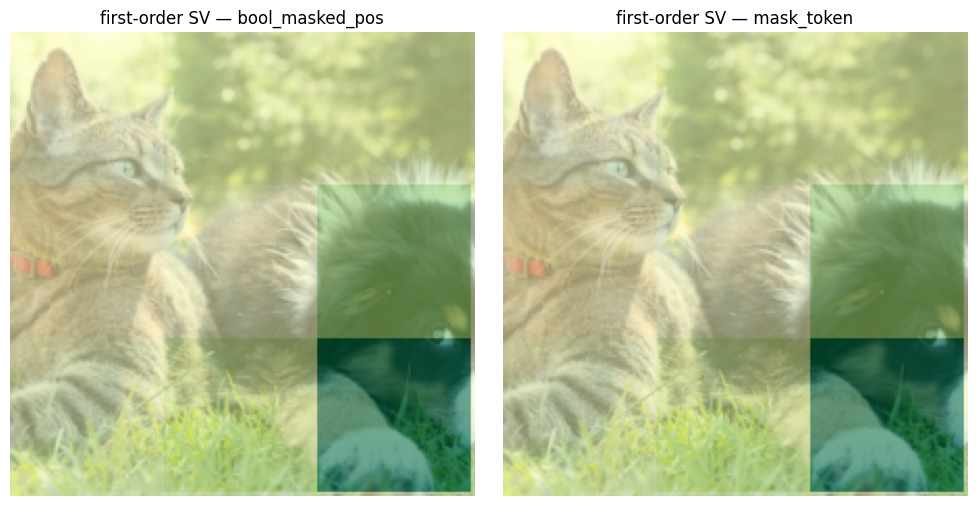

In [13]:
import matplotlib.colors as mcolors
from matplotlib import cm


def patch_heatmap(values, side=3, image_shape=image.shape):
    H, W = image_shape[:2]
    bh, bw = H // side, W // side
    heat = np.zeros((H, W))
    for i, v in enumerate(values):
        y, x = (i // side) * bh, (i % side) * bw
        heat[y : y + bh, x : x + bw] = v
    return heat


def overlay(ax, heat, title):
    ax.imshow(image)
    v = max(abs(heat.min()), abs(heat.max())) + 1e-9
    ax.imshow(
        heat, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55
    )
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sv_per_masker = {}
for ax, (name, ec) in zip(axes, computers.items(), strict=False):
    sv = ec.probabilistic_value(index="SV")
    sv_per_masker[name] = np.array([sv[(i,)] for i in range(9)])
    overlay(ax, patch_heatmap(sv_per_masker[name]), f"first-order SV — {name}")
plt.tight_layout()
plt.show()

## 4. Second-order interactions: k-SII and STII

k-SII order 2 decomposes the model's grand-coalition value into a first-order part (the standard SV) and a pairwise part that captures **interactions not explained by main effects**. STII gives a complementary view where each pair's value is its discrete second derivative.

Positive off-diagonal entries indicate synergy: the pair contributes more together than the sum of its marginal effects. Negative entries indicate redundancy: at least some evidence is shared between the two patches.


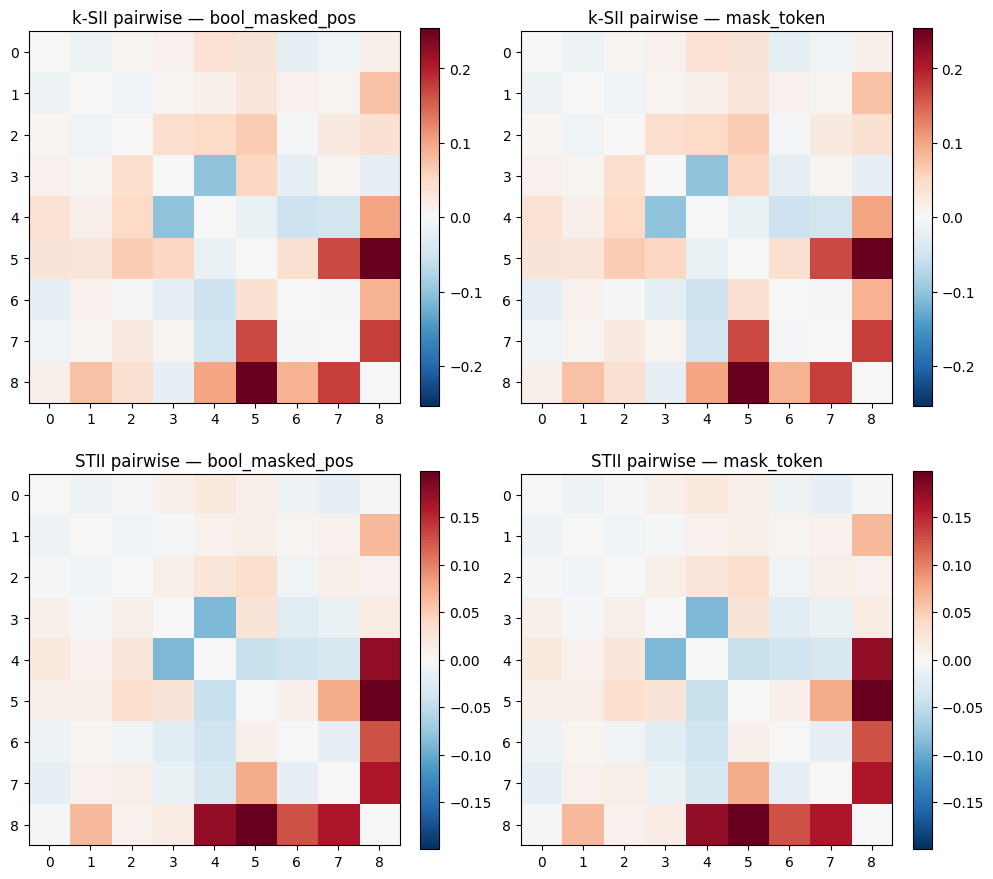

In [14]:
def pairwise_matrix(iv, n=9):
    """Off-diagonal pairwise interactions arranged as a symmetric (n, n) matrix."""
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            v = iv[(i, j)]
            mat[i, j] = v
            mat[j, i] = v
    return mat


ksii = {name: ec.shapley_interactions(index="k-SII", order=2) for name, ec in computers.items()}
stii = {name: ec.shapley_interactions(index="STII", order=2) for name, ec in computers.items()}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for col, (name, _) in enumerate(computers.items()):
    M_k = pairwise_matrix(ksii[name])
    M_s = pairwise_matrix(stii[name])
    for row, (M, label) in enumerate([(M_k, "k-SII"), (M_s, "STII")]):
        v = max(abs(M.min()), abs(M.max())) + 1e-9
        im = axes[row, col].imshow(
            M, cmap=cm.RdBu_r, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v)
        )
        axes[row, col].set_title(f"{label} pairwise — {name}")
        axes[row, col].set_xticks(range(9))
        axes[row, col].set_yticks(range(9))
        plt.colorbar(im, ax=axes[row, col], fraction=0.046)
plt.tight_layout()
plt.show()

## 5. How much do interactions add over first-order?

One way to quantify this is to split the variance of the game's value function across all $2^n$ coalition values into a first-order part and an interaction residual:

$$\operatorname{Var}\bigl(v(S)\bigr) = \underbrace{\operatorname{Var}\bigl(\hat v_1(S)\bigr)}_\text{first-order} + \underbrace{\operatorname{Var}\bigl(v(S) - \hat v_1(S)\bigr)}_\text{interaction residual} + \text{cross-terms}$$

We report $R^2$ of the additive reconstruction $\hat v_1(S) = v(\emptyset) + \sum_{i \in S} \phi_i$. A value close to 1 means first-order already captures most of the model's behaviour. A substantially lower value means interactions carry real signal.

In [15]:
from itertools import product

rows = []
for name, ec in computers.items():
    v_S = ec.game_values  # all 2^9 coalition values
    coalitions = np.array(list(product([0, 1], repeat=9)), dtype=bool)
    sv = sv_per_masker[name]
    v_empty = float(ec.baseline_value)
    additive = v_empty + coalitions @ sv
    # Re-order additive to match the ExactComputer's coalition_lookup order:
    additive_in_ec_order = np.zeros_like(v_S)
    for coal, vec in zip(coalitions, additive, strict=False):
        idx = ec.coalition_lookup[tuple(np.where(coal)[0])]
        additive_in_ec_order[idx] = vec
    ss_res = float(((v_S - additive_in_ec_order) ** 2).sum())
    ss_tot = float(((v_S - v_S.mean()) ** 2).sum())
    r2_additive = 1.0 - ss_res / max(ss_tot, 1e-12)
    rows.append((name, r2_additive))

print(f"{'masker':<20} {'R^2 of additive reconstruction':>30}")
for name, r2 in rows:
    print(f"{name:<20} {r2:>30.4f}")
print()
print(
    "Interpretation: 1.0 = first-order captures everything; lower values mean interactions matter."
)

masker               R^2 of additive reconstruction
bool_masked_pos                              0.4595
mask_token                                   0.4595

Interpretation: 1.0 = first-order captures everything; lower values mean interactions matter.


## 6. Strongest synergistic and redundant patch pairs

We extract the three most positive and three most negative pairwise k-SII entries for each masker.

- A **positive** entry means that removing both patches hurts the prediction more than removing them separately. The model uses them as a coupled pair.
- A **negative** entry means the patches carry overlapping evidence. Once one patch is present, the other adds little.


In [16]:
def top_pairs(M, k=3):
    triu = np.triu_indices_from(M, k=1)
    pairs = sorted(
        ((M[i, j], (i, j)) for i, j in zip(*triu, strict=False)),
        key=lambda x: x[0],
    )
    return pairs[-k:][::-1], pairs[:k]


for name in computers:
    M = pairwise_matrix(ksii[name])
    syn, red = top_pairs(M, k=3)
    print(f"\n— {name} —")
    print("  Top synergistic pairs (positive k-SII):")
    for v, (i, j) in syn:
        print(f"    patches ({i}, {j}) : {v:+.4f}")
    print("  Top redundant pairs (negative k-SII):")
    for v, (i, j) in red:
        print(f"    patches ({i}, {j}) : {v:+.4f}")


— bool_masked_pos —
  Top synergistic pairs (positive k-SII):
    patches (5, 8) : +0.2540
    patches (7, 8) : +0.1748
    patches (5, 7) : +0.1685
  Top redundant pairs (negative k-SII):
    patches (3, 4) : -0.1019
    patches (4, 6) : -0.0534
    patches (4, 7) : -0.0468

— mask_token —
  Top synergistic pairs (positive k-SII):
    patches (5, 8) : +0.2540
    patches (7, 8) : +0.1748
    patches (5, 7) : +0.1685
  Top redundant pairs (negative k-SII):
    patches (3, 4) : -0.1019
    patches (4, 6) : -0.0534
    patches (4, 7) : -0.0468


## 7. Robustness across masking strategies

As noted in Section 2, for `ViTForImageClassification` both maskers reduce to zero-token masking, so we expect $\rho = +1.000$. We confirm this below. The cell is kept as a template: with a MAE-style backbone (non-zero, learned mask_token) the two strategies would genuinely differ and $\rho < 1$ would indicate that interaction structure depends on how "absent" is defined.


In [17]:
from scipy.stats import spearmanr

M_a = pairwise_matrix(ksii["bool_masked_pos"])
M_b = pairwise_matrix(ksii["mask_token"])
iu = np.triu_indices_from(M_a, k=1)
rho, p = spearmanr(M_a[iu], M_b[iu])
print(f"Spearman ρ between the two maskers' pairwise k-SII: {rho:+.3f}  (p={p:.3g})")
print(
    "\nInterpretation: ρ close to 1 means the two maskers agree on which pairs interact.\n"
    "ρ closer to 0 means the interaction signal is driven by the masking choice as much as by the model."
)

Spearman ρ between the two maskers' pairwise k-SII: +1.000  (p=0)

Interpretation: ρ close to 1 means the two maskers agree on which pairs interact.
ρ closer to 0 means the interaction signal is driven by the masking choice as much as by the model.


## 8. Case study: visualising one synergistic pair

We identify the single strongest synergistic pair under `bool_masked_pos` and highlight those two patches on the image. The first-order SVs are shown as a backdrop to indicate where on the additive map the interaction sits.


Strongest synergistic pair: (5, 8) with k-SII = +0.2540


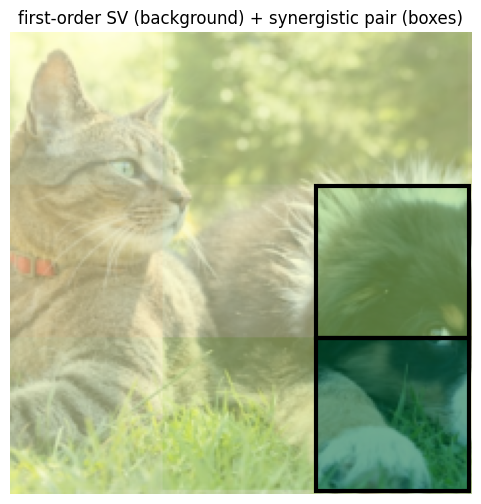

In [18]:
M = pairwise_matrix(ksii["bool_masked_pos"])
iu = np.triu_indices_from(M, k=1)
best_idx = int(np.argmax(M[iu]))
i_best, j_best = iu[0][best_idx], iu[1][best_idx]
print(f"Strongest synergistic pair: ({i_best}, {j_best}) with k-SII = {M[i_best, j_best]:+.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
overlay(
    ax,
    patch_heatmap(sv_per_masker["bool_masked_pos"]),
    "first-order SV (background) + synergistic pair (boxes)",
)

side, H = 3, image.shape[0]
bh = H // side
for p in (i_best, j_best):
    y, x = (p // side) * bh, (p % side) * bh
    ax.add_patch(plt.Rectangle((x, y), bh, bh, fill=False, edgecolor="black", linewidth=3))
plt.show()

## 9. Discussion

### What the numbers tell us

- **First-order does not capture everything.** The $R^2$ of the additive reconstruction falls below 1 for both maskers, confirming that pairwise interactions account for real variance in the game's value function. The remaining variance lives in the interaction residual, the part that the additive model cannot reconstruct.
- **Some pairs are coupled.** The strongest synergistic pair involves two adjacent patches whose joint removal hurts the prediction far more than either patch alone. These patches are not necessarily the individually strongest on the additive heatmap because their importance is a *joint* effect that is invisible to first-order Shapley values. This is the core reason for computing higher-order interactions.
- **Masking choice does not change the findings here.** The Spearman correlation between the two maskers' pairwise k-SII matrices is $\rho = +1.000$. As discussed in Section 2, for `ViTForImageClassification` (which has no pretrained mask token) both strategies collapse to zero-token masking, so identical results are expected by construction. On a model with a learned mask token, $\rho < 1$ would indicate that the definition of "absent" affects the interaction structure, an important caveat for downstream analysis.

### Limitations

- **Single image.** Findings on one image do not generalise. A proper study would aggregate results over a dataset.
- **9 players.** The 3×3 patch grid is a coarse discretisation. Finer grids would surface finer interactions but require approximate rather than exact computation.
- **Model fixed, masker varied.** This notebook holds the model fixed and varies the masking strategy. The companion notebook `04_cross_architecture.ipynb` takes the opposite approach: fixing the masker and varying the architecture.

### `shapiq` and this experiment

Computing $2^9=512$ exact coalition values and the full quadratic-order interaction decomposition requires only a few lines with `ExactComputer`. The same machinery scales to approximate computation for larger grids via `ImageExplainer`.